In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import ScalarFormatter

In [2]:
v2_benchmark_data = pd.read_csv("results/nwmapiv2/combine_api2_results.csv")
v2_benchmark_data.head()

,scenario,case,filter,elapsed_time_seconds,bytes_processed,job_id
0,retrospectives,case_01,HUC-0305010505,3.073945,1160000.0,8931e2bd-7403-4e49-947e-3d6a4aa61bc0
1,retrospectives,case_01,HUC-030501050505,1.415477,824.0,15a77a0d-93d3-4d88-aa7b-4217b9d43a19
2,retrospectives,case_01,Reach-12034579,1.348353,182.0,fff996d8-eda3-403a-a306-6b92ab8fc695
3,retrospectives,case_02,HUC-0305010505,13.280001,1160000.0,66d7cb13-7f2a-456b-82a2-a1ab73fb3fa0
4,retrospectives,case_02,HUC-030501050505,2.212323,824.0,9bc7bf19-fd76-4e4e-8c95-3ee5575b7bc1


In [3]:
v2_benchmark_data = v2_benchmark_data[v2_benchmark_data['case'].isin(['case_01', 'case_02'])]

In [4]:
v2_benchmark_data = v2_benchmark_data[v2_benchmark_data['bytes_processed'] > 0]

In [5]:
v2_benchmark_data.head()


,scenario,case,filter,elapsed_time_seconds,bytes_processed,job_id
0,retrospectives,case_01,HUC-0305010505,3.073945,1160000.0,8931e2bd-7403-4e49-947e-3d6a4aa61bc0
1,retrospectives,case_01,HUC-030501050505,1.415477,824.0,15a77a0d-93d3-4d88-aa7b-4217b9d43a19
2,retrospectives,case_01,Reach-12034579,1.348353,182.0,fff996d8-eda3-403a-a306-6b92ab8fc695
3,retrospectives,case_02,HUC-0305010505,13.280001,1160000.0,66d7cb13-7f2a-456b-82a2-a1ab73fb3fa0
4,retrospectives,case_02,HUC-030501050505,2.212323,824.0,9bc7bf19-fd76-4e4e-8c95-3ee5575b7bc1


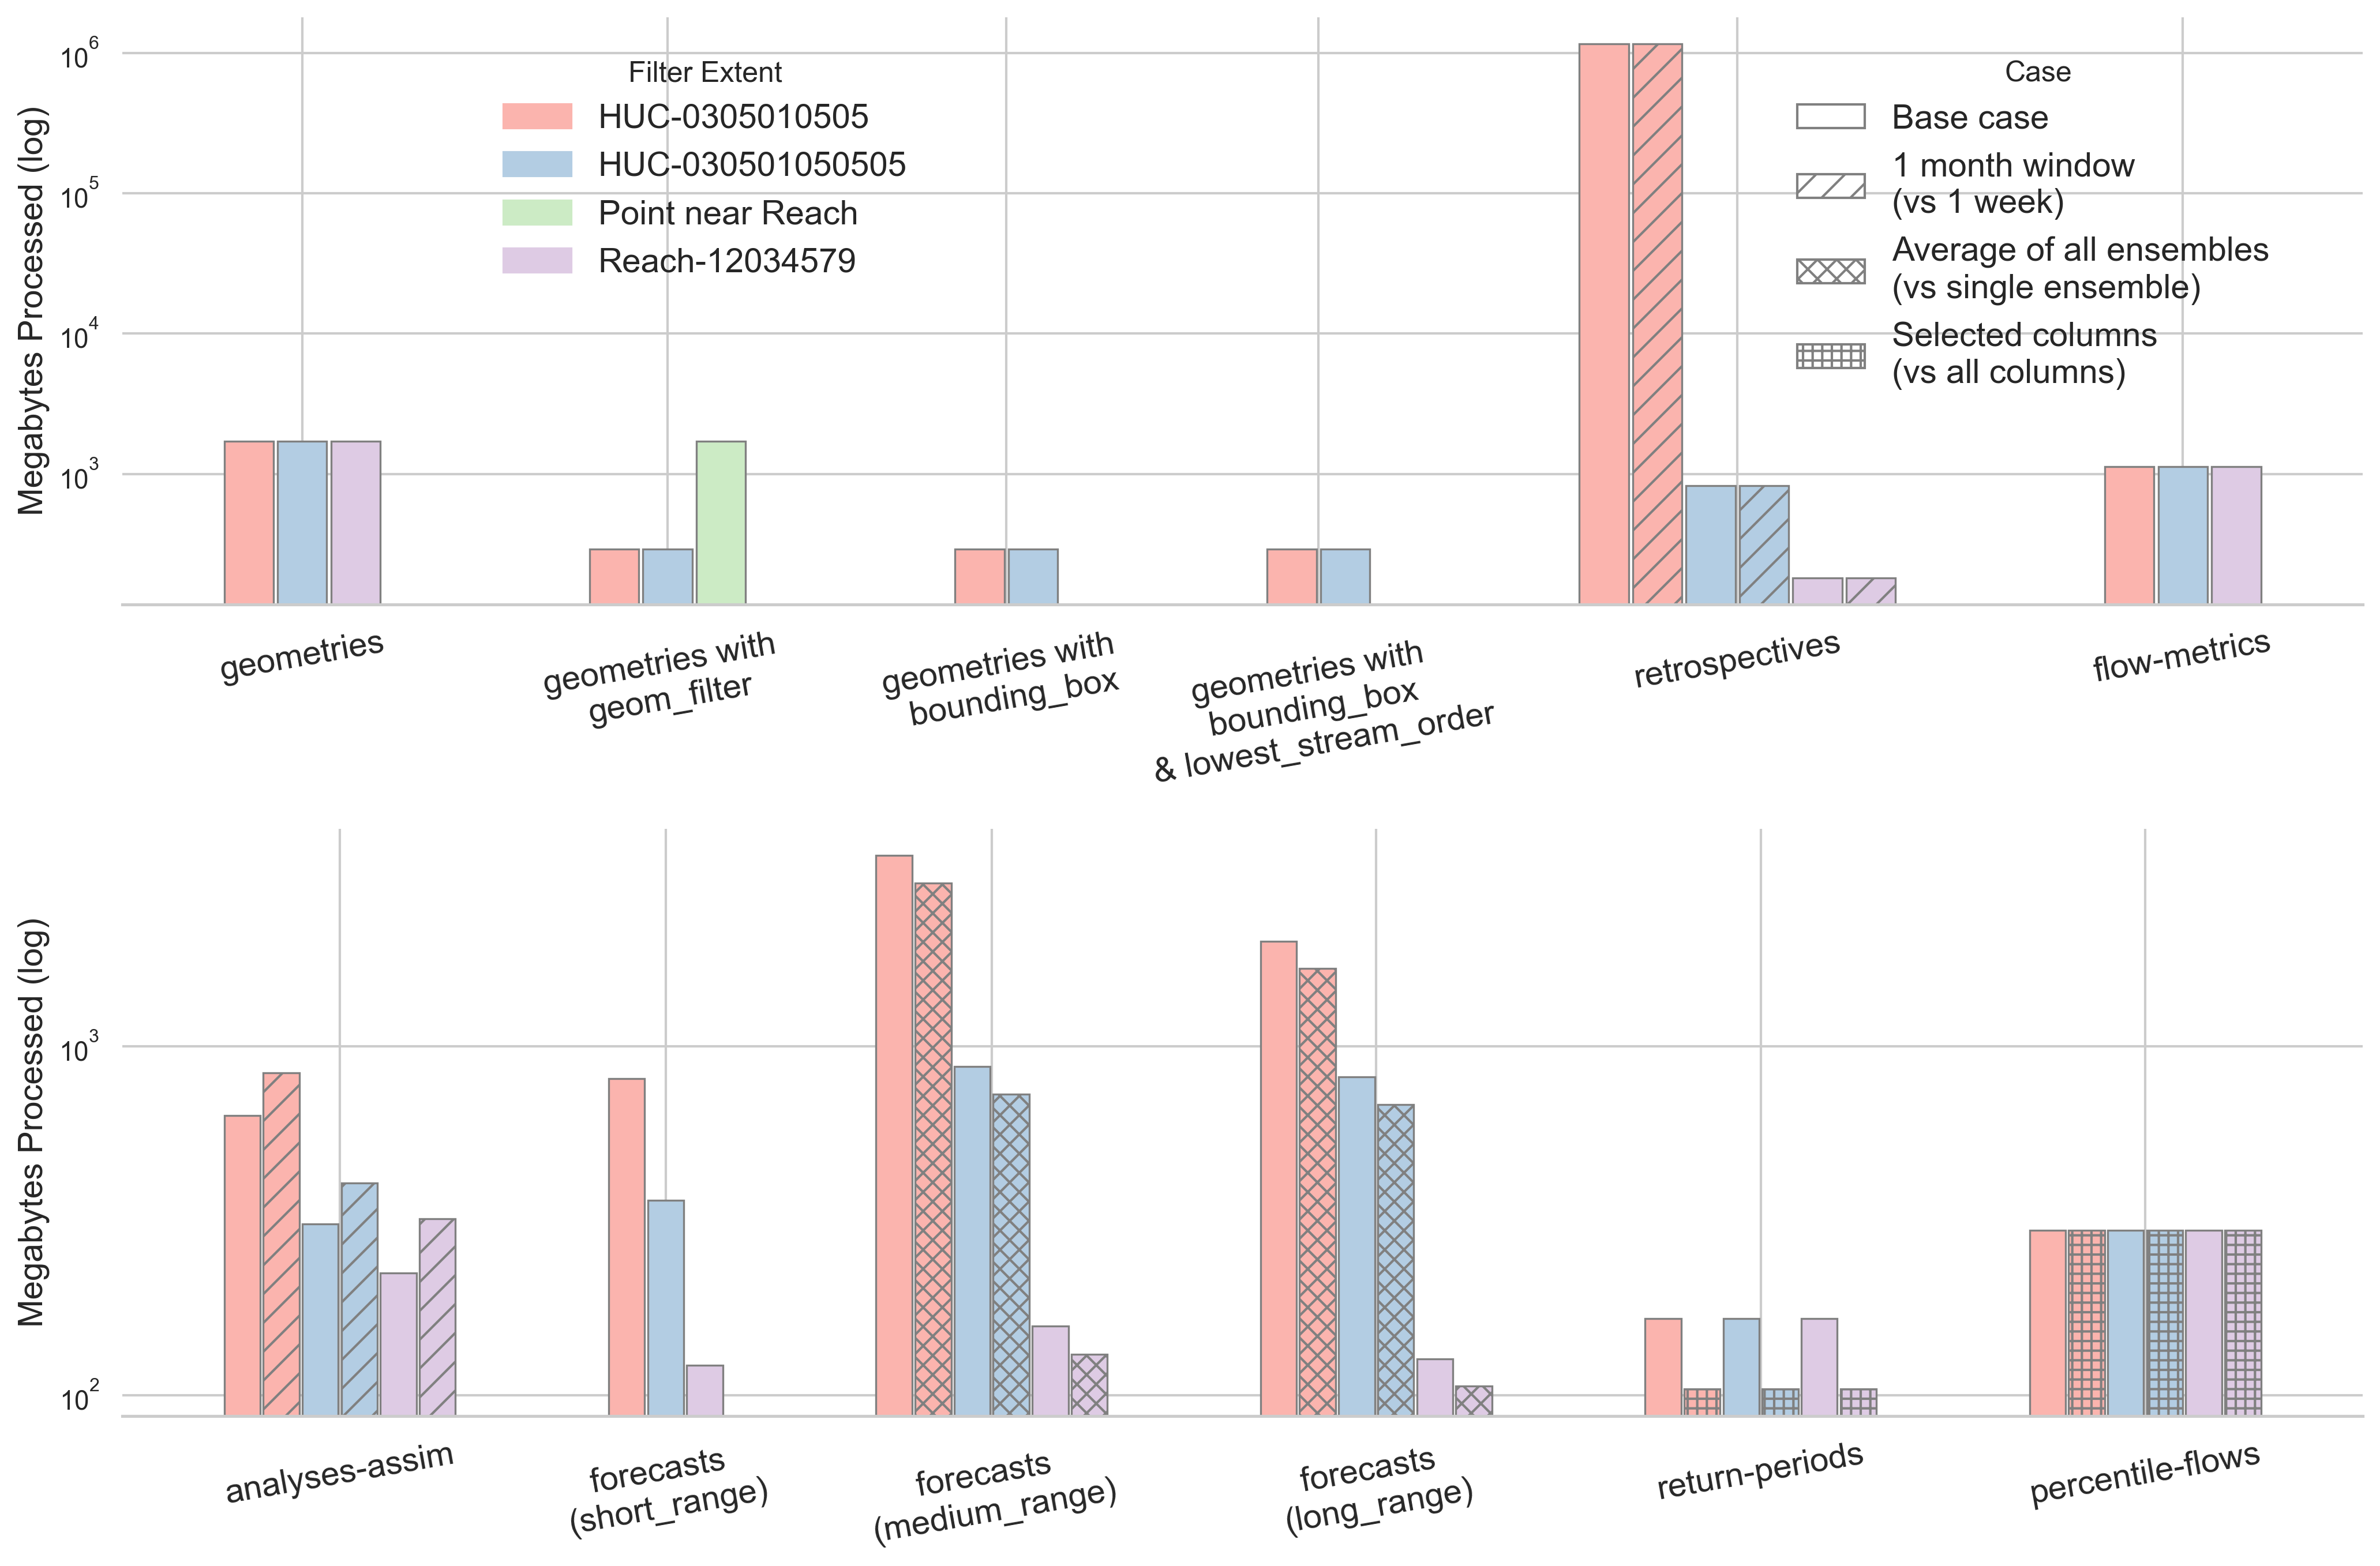

In [6]:
group_a_keys = ['geometries', 'geometries_with_geom_filter', 'geometries_with_bbox', 'geometries_with_bbox_and_stream_order_filter', 'retrospectives', 'flow-metrics', ]
group_b_keys = ['analyses-assim', 'short_range_forecast', 'medium_range_forecast', 'long_range_forecast', 'return_periods', 'percentile-flows']
name_map = {'geometries': 'geometries',
            'geometries_with_bbox': 'geometries with \n bounding_box',
            'geometries_with_bbox_and_stream_order_filter': 'geometries with \nbounding_box \n& lowest_stream_order',
            'retrospectives': 'retrospectives',
            'flow-metrics': 'flow-metrics',
            'percentile-flows': 'percentile-flows',
            'geometries_with_geom_filter': 'geometries with \ngeom_filter',
            'analyses-assim': 'analyses-assim',
            'short_range_forecast': 'forecasts \n(short_range)',
            'medium_range_forecast': 'forecasts \n(medium_range)',
            'long_range_forecast': 'forecasts \n(long_range)',
            'return_periods': 'return-periods'}

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 15, 'figure.dpi': 300, 'font.family': 'sans-serif'})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
plt.subplots_adjust(hspace=0.4)

filters = sorted(v2_benchmark_data['filter'].unique())
cases = sorted(v2_benchmark_data['case'].unique())
color_map = dict(zip(filters, sns.color_palette("Pastel1", len(filters))))
hatch_map_1 = {cases[0]: '', cases[1]: '//'}
hatch_map_2 = {cases[0]: '', cases[1]: 'xxx'}
hatch_map_3 = {cases[0]: '', cases[1]: '+++'}

hatch_map = {'Base case': '',
             '1 month window \n(vs 1 week)': '//',
             'Average of all ensembles \n(vs single ensemble)': 'xxx',
             'Selected columns \n(vs all columns)': '+++'
}

def plot_group(ax, scenario_keys):
    bar_width, inter_bar_gap, cluster_gap = 0.12, 0.01, 0.5
    current_x = 0
    xticks, xtick_labels = [], []
    
    for s_key in scenario_keys:
        scenario_df = v2_benchmark_data[v2_benchmark_data['scenario'] == s_key]
        if scenario_df.empty: continue
        if s_key in ['retrospectives', 'analyses-assim']:
            hatch_map = hatch_map_1
        elif s_key in ['long_range_forecast', 'medium_range_forecast']:            
            hatch_map = hatch_map_2
        else:
            hatch_map = hatch_map_3
        start_x = current_x
        for f in filters:
            for c in cases:
                row = scenario_df[(scenario_df['filter'] == f) & (scenario_df['case'] == c)]
                if not row.empty:
                    val = row['bytes_processed'].values[0]
                    ax.bar(current_x, val, width=bar_width, color=color_map[f],
                           edgecolor='grey', hatch=hatch_map[c], linewidth=0.8)
                    current_x += (bar_width + inter_bar_gap)
        
        # Centering the renamed label
        xticks.append((start_x + current_x - (bar_width + inter_bar_gap)) / 2)
        xtick_labels.append(name_map[s_key].lower()) # lowercase as requested previously
        current_x += cluster_gap

    ax.set_yscale('log')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14, rotation=10)
    ax.set_ylabel('Megabytes Processed (log)', fontsize=14)
    sns.despine(ax=ax, left=True)

plot_group(ax1, group_a_keys)
plot_group(ax2, group_b_keys)

filter_patches = [mpatches.Patch(color=color_map[f], label=f) for f in filters]
case_patches = [mpatches.Patch(facecolor='white', edgecolor='grey', hatch=hatch_map[c], label=c) for c in hatch_map.keys()]

fig.legend(handles=filter_patches, title="Filter Extent", loc='upper center', 
           bbox_to_anchor=(0.3, 0.9), ncol=1, frameon=False, fontsize=14)
fig.legend(handles=case_patches, title="Case", loc='upper center', 
           bbox_to_anchor=(0.85, 0.9), ncol=1, frameon=False, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("figures/comparison_for_cost_implications.png", dpi=300)
plt.savefig("figures/comparison_for_cost_implications.pdf", dpi=300)
plt.show()